In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

print("All libraries loaded successfully!")

In [ ]:
def quat_mult(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ])

def quat_conj(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def quat_norm(q):
    return q / np.linalg.norm(q)

def quat_to_euler(q):
    w, x, y, z = q
    roll  = np.degrees(np.arctan2(2*(w*x + y*z), 1 - 2*(x*x + y*y)))
    pitch = np.degrees(np.arcsin(np.clip(2*(w*y - z*x), -1, 1)))
    yaw   = np.degrees(np.arctan2(2*(w*z + x*y), 1 - 2*(y*y + z*z)))
    return np.array([roll, pitch, yaw])

print("Quaternion functions defined!")

In [ ]:
# CubeSat inertia tensor (3U, kg·m²)
I = np.diag([0.004, 0.004, 0.002])
I_inv = np.linalg.inv(I)

# PD controller gains
Kp = 0.015
Kd = 0.005

def attitude_dynamics(t, state, q_ref):
    q = quat_norm(state[:4])
    w = state[4:]

    # Error quaternion
    q_err = quat_mult(quat_conj(q_ref), q)
    if q_err[0] < 0:
        q_err = -q_err

    e_vec = q_err[1:]

    # Control torque
    torque = -Kp * e_vec - Kd * w

    # Quaternion kinematics
    w_quat = np.array([0.0, w[0], w[1], w[2]])
    q_dot = 0.5 * quat_mult(q, w_quat)

    # Euler rigid body equations
    w_dot = I_inv @ (torque - np.cross(w, I @ w))

    return np.concatenate([q_dot, w_dot])

print("Dynamics model ready!")

In [ ]:
# Target attitude (no rotation)
q_ref = np.array([1.0, 0.0, 0.0, 0.0])

# Initial condition: 30° off-axis with a small spin
angle = np.radians(30)
q0 = np.array([np.cos(angle/2), np.sin(angle/2)*0.6,
                np.sin(angle/2)*0.8, 0.0])
q0 = quat_norm(q0)
w0 = np.array([0.05, -0.03, 0.02])

state0 = np.concatenate([q0, w0])
t_span = (0, 120)
t_eval = np.linspace(*t_span, 1200)

sol = solve_ivp(
    attitude_dynamics, t_span, state0,
    t_eval=t_eval, args=(q_ref,),
    method='RK45', rtol=1e-8, atol=1e-10
)

# Normalize quaternions and extract Euler angles
qs = np.array([quat_norm(sol.y[:4, i]) for i in range(sol.y.shape[1])])
ws = sol.y[4:].T
eulers = np.array([quat_to_euler(q) for q in qs])

print("Simulation complete!")
print(f"Final attitude error: {eulers[-1].round(4)} degrees")

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Euler angles
axes[0].plot(sol.t, eulers[:, 0], label='Roll')
axes[0].plot(sol.t, eulers[:, 1], label='Pitch')
axes[0].plot(sol.t, eulers[:, 2], label='Yaw')
axes[0].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[0].set_ylabel('Angle (deg)')
axes[0].set_title('Euler angles (ZYX)')
axes[0].legend()

# Angular velocity
axes[1].plot(sol.t, ws[:, 0], label='ωx')
axes[1].plot(sol.t, ws[:, 1], label='ωy')
axes[1].plot(sol.t, ws[:, 2], label='ωz')
axes[1].set_ylabel('ω (rad/s)')
axes[1].set_title('Angular velocity (body frame)')
axes[1].legend()

# Quaternion norm
norms = np.linalg.norm(qs, axis=1)
axes[2].plot(sol.t, norms, color='gray')
axes[2].set_ylim(0.999, 1.001)
axes[2].set_ylabel('|q|')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Quaternion norm (drift check)')

plt.tight_layout()
plt.show()

In [ ]:
# ---- Realistic simulation parameters ----

# CubeSat inertia tensor (3U, kg·m²)
I = np.diag([0.004, 0.004, 0.002])
I_inv = np.linalg.inv(I)

# PD gains
Kp = 0.015
Kd = 0.005

# --- 1. SENSOR NOISE ---
# Real gyroscopes don't measure angular velocity perfectly.
# They have a slowly drifting bias + random noise on every reading.
gyro_noise_std = 0.001      # random noise  (rad/s) — small jitter each step
gyro_bias      = np.array([0.0005, -0.0003, 0.0002])  # constant drift

# --- 2. ACTUATOR LIMITS ---
# Reaction wheels can't produce infinite torque.
# If you command more than the limit, it just clips at the max.
max_torque = 0.001   # 1 mNm — typical for a 3U CubeSat wheel

# --- 3. DISTURBANCE TORQUES ---
# Three real disturbances acting on the satellite constantly:
# a) Gravity gradient — uneven gravity pull across the spacecraft body
# b) Solar radiation pressure — photons pushing on the panels
# c) Residual magnetic dipole — tiny magnetic field in the electronics

def disturbance_torques(t, q):
    """Returns a small random disturbance torque vector (N·m)."""
    # Gravity gradient torque (simplified, orbit-dependent)
    gravity_gradient = np.array([1e-6 * np.sin(0.001 * t),
                                  1e-6 * np.cos(0.001 * t),
                                  5e-7 * np.sin(0.002 * t)])
    # Solar radiation pressure (tiny constant push)
    solar_pressure = np.array([2e-7, -1e-7, 1e-7])

    # Magnetic disturbance (oscillates with orbit)
    magnetic = np.array([3e-7 * np.sin(0.003 * t),
                         2e-7 * np.cos(0.003 * t),
                         1e-7 * np.sin(0.001 * t)])
    return gravity_gradient + solar_pressure + magnetic

print("Realistic parameters defined!")

In [ ]:
def attitude_dynamics_realistic(t, state, q_ref):
    q = quat_norm(state[:4])
    w = state[4:]

    # --- 1. ADD SENSOR NOISE to angular velocity reading ---
    # The controller doesn't see the true w, it sees w + noise + bias
    noise = np.random.normal(0, gyro_noise_std, 3)
    w_measured = w + noise + gyro_bias

    # --- 2. COMPUTE ERROR using noisy measurement ---
    q_err = quat_mult(quat_conj(q_ref), q)
    if q_err[0] < 0:
        q_err = -q_err
    e_vec = q_err[1:]

    # --- 3. COMPUTE CONTROL TORQUE ---
    torque = -Kp * e_vec - Kd * w_measured

    # --- 4. CLIP TORQUE to actuator limit (reaction wheel saturation) ---
    torque = np.clip(torque, -max_torque, max_torque)

    # --- 5. ADD DISTURBANCE TORQUES ---
    torque_total = torque + disturbance_torques(t, q)

    # --- 6. QUATERNION KINEMATICS (same as before) ---
    w_quat = np.array([0.0, w[0], w[1], w[2]])
    q_dot = 0.5 * quat_mult(q, w_quat)

    # --- 7. EULER RIGID BODY EQUATIONS with total torque ---
    w_dot = I_inv @ (torque_total - np.cross(w, I @ w))

    return np.concatenate([q_dot, w_dot])

print("Realistic dynamics model ready!")

In [ ]:
# --- 4. TRIAD ALGORITHM ---
# In reality the satellite doesn't know its own orientation perfectly.
# It has two sensors:
#   - A magnetometer: measures Earth's magnetic field direction
#   - A sun sensor: measures the direction of the sun
# TRIAD takes these two measured vectors + their known reference directions
# and computes the best estimate of the current attitude.

def triad(v1_body, v2_body, v1_ref, v2_ref):
    """
    Estimate rotation matrix from two vector pairs.
    v1_body, v2_body = vectors measured by sensors in body frame
    v1_ref,  v2_ref  = same vectors known in inertial reference frame
    Returns: 3x3 rotation matrix (body to inertial)
    """
    # Normalize all vectors
    v1_body = v1_body / np.linalg.norm(v1_body)
    v2_body = v2_body / np.linalg.norm(v2_body)
    v1_ref  = v1_ref  / np.linalg.norm(v1_ref)
    v2_ref  = v2_ref  / np.linalg.norm(v2_ref)

    # Build triad basis vectors in body frame
    t1_b = v1_body
    t2_b = np.cross(v1_body, v2_body)
    t2_b = t2_b / np.linalg.norm(t2_b)
    t3_b = np.cross(t1_b, t2_b)

    # Build triad basis vectors in reference frame
    t1_r = v1_ref
    t2_r = np.cross(v1_ref, v2_ref)
    t2_r = t2_r / np.linalg.norm(t2_r)
    t3_r = np.cross(t1_r, t2_r)

    # Rotation matrix: reference → body
    M_body = np.column_stack([t1_b, t2_b, t3_b])
    M_ref  = np.column_stack([t1_r, t2_r, t3_r])
    R = M_body @ M_ref.T
    return R

def rotation_matrix_to_quaternion(R):
    """Convert a 3x3 rotation matrix to a unit quaternion [w,x,y,z]."""
    trace = R[0,0] + R[1,1] + R[2,2]
    if trace > 0:
        s = 0.5 / np.sqrt(trace + 1.0)
        w = 0.25 / s
        x = (R[2,1] - R[1,2]) * s
        y = (R[0,2] - R[2,0]) * s
        z = (R[1,0] - R[0,1]) * s
    else:
        if R[0,0] > R[1,1] and R[0,0] > R[2,2]:
            s = 2.0 * np.sqrt(1.0 + R[0,0] - R[1,1] - R[2,2])
            w = (R[2,1] - R[1,2]) / s
            x = 0.25 * s
            y = (R[0,1] + R[1,0]) / s
            z = (R[0,2] + R[2,0]) / s
        elif R[1,1] > R[2,2]:
            s = 2.0 * np.sqrt(1.0 + R[1,1] - R[0,0] - R[2,2])
            w = (R[0,2] - R[2,0]) / s
            x = (R[0,1] + R[1,0]) / s
            y = 0.25 * s
            z = (R[1,2] + R[2,1]) / s
        else:
            s = 2.0 * np.sqrt(1.0 + R[2,2] - R[0,0] - R[1,1])
            w = (R[1,0] - R[0,1]) / s
            x = (R[0,2] + R[2,0]) / s
            y = (R[1,2] + R[2,1]) / s
            z = 0.25 * s
    return quat_norm(np.array([w, x, y, z]))

def simulate_sensors(q_true, t):
    """
    Simulate what the magnetometer and sun sensor actually measure.
    They measure the true direction + a small amount of sensor noise.
    """
    # Known reference vectors in inertial frame
    mag_ref = np.array([0.3, 0.5, 0.8])   # Earth magnetic field direction
    sun_ref = np.array([1.0, 0.0, 0.0])   # Sun direction (simplified)

    # Rotate reference vectors into body frame using true quaternion
    # (in reality the satellite measures these directly with hardware)
    w_true = np.array([0.0, *mag_ref])
    mag_body = quat_mult(quat_mult(quat_conj(q_true), w_true), q_true)[1:]

    w_true2 = np.array([0.0, *sun_ref])
    sun_body = quat_mult(quat_mult(quat_conj(q_true), w_true2), q_true)[1:]

    # Add sensor noise (real sensors aren't perfect)
    mag_body += np.random.normal(0, 0.01, 3)
    sun_body += np.random.normal(0, 0.01, 3)

    return mag_body, sun_body, mag_ref, sun_ref

print("TRIAD algorithm ready!")

In [ ]:
# Target attitude
q_ref = np.array([1.0, 0.0, 0.0, 0.0])

# Initial condition: 30° off-axis with a small spin
angle = np.radians(30)
q0 = np.array([np.cos(angle/2), np.sin(angle/2)*0.6,
                np.sin(angle/2)*0.8, 0.0])
q0 = quat_norm(q0)
w0 = np.array([0.05, -0.03, 0.02])

state0 = np.concatenate([q0, w0])
t_span = (0, 120)
t_eval = np.linspace(*t_span, 1200)

# Run simulation
sol = solve_ivp(
    attitude_dynamics_realistic, t_span, state0,
    t_eval=t_eval, args=(q_ref,),
    method='RK45', rtol=1e-8, atol=1e-10
)

# Extract results
qs = np.array([quat_norm(sol.y[:4, i]) for i in range(sol.y.shape[1])])
ws = sol.y[4:].T
eulers = np.array([quat_to_euler(q) for q in qs])

# Run TRIAD at each timestep to get estimated attitude
triad_eulers = []
for i in range(len(sol.t)):
    q_true = qs[i]
    mag_body, sun_body, mag_ref, sun_ref = simulate_sensors(q_true, sol.t[i])
    R_est = triad(mag_body, sun_body, mag_ref, sun_ref)
    q_est = rotation_matrix_to_quaternion(R_est)
    triad_eulers.append(quat_to_euler(q_est))

triad_eulers = np.array(triad_eulers)

print("Realistic simulation complete!")
print(f"Final true attitude:      {eulers[-1].round(4)} degrees")
print(f"Final TRIAD estimate:     {triad_eulers[-1].round(4)} degrees")
print(f"Estimation error:         {(eulers[-1] - triad_eulers[-1]).round(4)} degrees")

In [ ]:
# Target attitude
q_ref = np.array([1.0, 0.0, 0.0, 0.0])

# Initial condition: 30° off-axis with a small spin
angle = np.radians(30)
q0 = np.array([np.cos(angle/2), np.sin(angle/2)*0.6,
                np.sin(angle/2)*0.8, 0.0])
q0 = quat_norm(q0)
w0 = np.array([0.05, -0.03, 0.02])

state0 = np.concatenate([q0, w0])
t_span = (0, 120)
t_eval = np.linspace(*t_span, 1200)

# Run simulation
sol = solve_ivp(
    attitude_dynamics_realistic, t_span, state0,
    t_eval=t_eval, args=(q_ref,),
    method='RK45', rtol=1e-8, atol=1e-10
)

# Extract results
qs = np.array([quat_norm(sol.y[:4, i]) for i in range(sol.y.shape[1])])
ws = sol.y[4:].T
eulers = np.array([quat_to_euler(q) for q in qs])

# Run TRIAD at each timestep to get estimated attitude
triad_eulers = []
for i in range(len(sol.t)):
    q_true = qs[i]
    mag_body, sun_body, mag_ref, sun_ref = simulate_sensors(q_true, sol.t[i])
    R_est = triad(mag_body, sun_body, mag_ref, sun_ref)
    q_est = rotation_matrix_to_quaternion(R_est)
    triad_eulers.append(quat_to_euler(q_est))

triad_eulers = np.array(triad_eulers)

print("Realistic simulation complete!")
print(f"Final true attitude:      {eulers[-1].round(4)} degrees")
print(f"Final TRIAD estimate:     {triad_eulers[-1].round(4)} degrees")
print(f"Estimation error:         {(eulers[-1] - triad_eulers[-1]).round(4)} degrees")

In [ ]:
# Target attitude
q_ref = np.array([1.0, 0.0, 0.0, 0.0])

# Initial condition: 30° off-axis with a small spin
angle = np.radians(30)
q0 = np.array([np.cos(angle/2), np.sin(angle/2)*0.6,
                np.sin(angle/2)*0.8, 0.0])
q0 = quat_norm(q0)
w0 = np.array([0.05, -0.03, 0.02])

state0 = np.concatenate([q0, w0])
t_span = (0, 120)
t_eval = np.linspace(*t_span, 1200)

# Run simulation
sol = solve_ivp(
    attitude_dynamics_realistic, t_span, state0,
    t_eval=t_eval, args=(q_ref,),
    method='RK45', rtol=1e-8, atol=1e-10
)

# Extract results
qs = np.array([quat_norm(sol.y[:4, i]) for i in range(sol.y.shape[1])])
ws = sol.y[4:].T
eulers = np.array([quat_to_euler(q) for q in qs])

# Run TRIAD at each timestep to get estimated attitude
triad_eulers = []
for i in range(len(sol.t)):
    q_true = qs[i]
    mag_body, sun_body, mag_ref, sun_ref = simulate_sensors(q_true, sol.t[i])
    R_est = triad(mag_body, sun_body, mag_ref, sun_ref)
    q_est = rotation_matrix_to_quaternion(R_est)
    triad_eulers.append(quat_to_euler(q_est))

triad_eulers = np.array(triad_eulers)

print("Realistic simulation complete!")
print(f"Final true attitude:      {eulers[-1].round(4)} degrees")
print(f"Final TRIAD estimate:     {triad_eulers[-1].round(4)} degrees")
print(f"Estimation error:         {(eulers[-1] - triad_eulers[-1]).round(4)} degrees")

In [ ]:
print("Step 1: starting...")

# Test just the simulation first without TRIAD
sol = solve_ivp(
    attitude_dynamics_realistic, (0, 10), state0,
    t_eval=np.linspace(0, 10, 100), args=(q_ref,),
    method='RK45', rtol=1e-6, atol=1e-8
)

print("Step 2: simulation done...")

# Test TRIAD on just one timestep
q_true = quat_norm(sol.y[:4, 0])
mag_body, sun_body, mag_ref, sun_ref = simulate_sensors(q_true, 0)
print("Step 3: sensors simulated...")

R_est = triad(mag_body, sun_body, mag_ref, sun_ref)
print("Step 4: TRIAD done...")

q_est = rotation_matrix_to_quaternion(R_est)
print("Step 5: quaternion conversion done...")

print("All steps passed! Safe to run full simulation.")

In [ ]:
print("Step 1: starting...")

# Test just the simulation first without TRIAD
sol = solve_ivp(
    attitude_dynamics_realistic, (0, 10), state0,
    t_eval=np.linspace(0, 10, 100), args=(q_ref,),
    method='RK45', rtol=1e-6, atol=1e-8
)

print("Step 2: simulation done...")

# Test TRIAD on just one timestep
q_true = quat_norm(sol.y[:4, 0])
mag_body, sun_body, mag_ref, sun_ref = simulate_sensors(q_true, 0)
print("Step 3: sensors simulated...")

R_est = triad(mag_body, sun_body, mag_ref, sun_ref)
print("Step 4: TRIAD done...")

q_est = rotation_matrix_to_quaternion(R_est)
print("Step 5: quaternion conversion done...")

print("All steps passed! Safe to run full simulation.")

In [ ]:
print(state0, q_ref)

In [ ]:
# Target attitude
q_ref = np.array([1.0, 0.0, 0.0, 0.0])

# Initial condition: 30° off-axis with a small spin
angle = np.radians(30)
q0 = np.array([np.cos(angle/2), np.sin(angle/2)*0.6,
                np.sin(angle/2)*0.8, 0.0])
q0 = quat_norm(q0)
w0 = np.array([0.05, -0.03, 0.02])
state0 = np.concatenate([q0, w0])

# Shorter simulation + looser tolerances = much faster
t_span = (0, 120)
t_eval = np.linspace(*t_span, 600)   # 600 points instead of 1200

sol = solve_ivp(
    attitude_dynamics_realistic, t_span, state0,
    t_eval=t_eval, args=(q_ref,),
    method='RK45', rtol=1e-6, atol=1e-8   # looser = faster
)

# Extract results
qs = np.array([quat_norm(sol.y[:4, i]) for i in range(sol.y.shape[1])])
ws = sol.y[4:].T
eulers = np.array([quat_to_euler(q) for q in qs])

# TRIAD every 10th step only (we don't need it at every single point)
triad_eulers = []
triad_times = []
for i in range(0, len(sol.t), 10):
    q_true = qs[i]
    mag_body, sun_body, mag_ref, sun_ref = simulate_sensors(q_true, sol.t[i])
    R_est = triad(mag_body, sun_body, mag_ref, sun_ref)
    q_est = rotation_matrix_to_quaternion(R_est)
    triad_eulers.append(quat_to_euler(q_est))
    triad_times.append(sol.t[i])

triad_eulers = np.array(triad_eulers)
triad_times = np.array(triad_times)

print("Realistic simulation complete!")
print(f"Final true attitude:  {eulers[-1].round(4)} degrees")
print(f"Final TRIAD estimate: {triad_eulers[-1].round(4)} degrees")
print(f"Estimation error:     {(eulers[-1] - triad_eulers[-1]).round(4)} degrees")

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ---- Quaternion functions ----
def quat_mult(q1, q2):
    w1,x1,y1,z1 = q1
    w2,x2,y2,z2 = q2
    return np.array([
        w1*w2-x1*x2-y1*y2-z1*z2,
        w1*x2+x1*w2+y1*z2-z1*y2,
        w1*y2-x1*z2+y1*w2+z1*x2,
        w1*z2+x1*y2-y1*x2+z1*w2])

def quat_conj(q):
    return np.array([q[0],-q[1],-q[2],-q[3]])

def quat_norm(q):
    return q/np.linalg.norm(q)

def quat_to_euler(q):
    w,x,y,z = q
    roll  = np.degrees(np.arctan2(2*(w*x+y*z),1-2*(x*x+y*y)))
    pitch = np.degrees(np.arcsin(np.clip(2*(w*y-z*x),-1,1)))
    yaw   = np.degrees(np.arctan2(2*(w*z+x*y),1-2*(y*y+z*z)))
    return np.array([roll,pitch,yaw])

def rotation_matrix_to_quaternion(R):
    trace = R[0,0]+R[1,1]+R[2,2]
    if trace > 0:
        s = 0.5/np.sqrt(trace+1.0)
        w = 0.25/s
        x = (R[2,1]-R[1,2])*s
        y = (R[0,2]-R[2,0])*s
        z = (R[1,0]-R[0,1])*s
    elif R[0,0]>R[1,1] and R[0,0]>R[2,2]:
        s = 2.0*np.sqrt(1.0+R[0,0]-R[1,1]-R[2,2])
        w = (R[2,1]-R[1,2])/s
        x = 0.25*s
        y = (R[0,1]+R[1,0])/s
        z = (R[0,2]+R[2,0])/s
    elif R[1,1]>R[2,2]:
        s = 2.0*np.sqrt(1.0+R[1,1]-R[0,0]-R[2,2])
        w = (R[0,2]-R[2,0])/s
        x = (R[0,1]+R[1,0])/s
        y = 0.25*s
        z = (R[1,2]+R[2,1])/s
    else:
        s = 2.0*np.sqrt(1.0+R[2,2]-R[0,0]-R[1,1])
        w = (R[1,0]-R[0,1])/s
        x = (R[0,2]+R[2,0])/s
        y = (R[1,2]+R[2,1])/s
        z = 0.25*s
    return quat_norm(np.array([w,x,y,z]))

# ---- Parameters ----
I     = np.diag([0.004, 0.004, 0.002])
I_inv = np.linalg.inv(I)
Kp    = 0.015
Kd    = 0.005
max_torque  = 0.001
gyro_bias   = np.array([0.0005, -0.0003, 0.0002])
gyro_noise  = 0.001

# ---- Disturbances ----
def disturbances(t):
    grav = np.array([1e-6*np.sin(0.001*t), 1e-6*np.cos(0.001*t), 5e-7*np.sin(0.002*t)])
    solar = np.array([2e-7, -1e-7, 1e-7])
    mag  = np.array([3e-7*np.sin(0.003*t), 2e-7*np.cos(0.003*t), 1e-7*np.sin(0.001*t)])
    return grav + solar + mag

# ---- Dynamics (no random inside ODE) ----
def dynamics(t, state, q_ref):
    q = quat_norm(state[:4])
    w = state[4:]
    w_measured = w + gyro_bias        # bias only, no random inside ODE
    q_err = quat_mult(quat_conj(q_ref), q)
    if q_err[0] < 0:
        q_err = -q_err
    torque = np.clip(-Kp*q_err[1:] - Kd*w_measured, -max_torque, max_torque)
    torque_total = torque + disturbances(t)
    q_dot = 0.5*quat_mult(q, np.array([0.0, w[0], w[1], w[2]]))
    w_dot = I_inv@(torque_total - np.cross(w, I@w))
    return np.concatenate([q_dot, w_dot])

# ---- TRIAD ----
def triad(v1b, v2b, v1r, v2r):
    v1b=v1b/np.linalg.norm(v1b); v2b=v2b/np.linalg.norm(v2b)
    v1r=v1r/np.linalg.norm(v1r); v2r=v2r/np.linalg.norm(v2r)
    t1b=v1b; t2b=np.cross(v1b,v2b); t2b/=np.linalg.norm(t2b); t3b=np.cross(t1b,t2b)
    t1r=v1r; t2r=np.cross(v1r,v2r); t2r/=np.linalg.norm(t2r); t3r=np.cross(t1r,t2r)
    return np.column_stack([t1b,t2b,t3b])@np.column_stack([t1r,t2r,t3r]).T

def simulate_sensors(q_true):
    mag_ref = np.array([0.3, 0.5, 0.8])
    sun_ref = np.array([1.0, 0.0, 0.0])
    def rotate(v):
        w = np.array([0.0,*v])
        return quat_mult(quat_mult(quat_conj(q_true),w),q_true)[1:]
    mag_body = rotate(mag_ref) + np.random.normal(0,0.01,3)
    sun_body = rotate(sun_ref) + np.random.normal(0,0.01,3)
    return mag_body, sun_body, mag_ref, sun_ref

# ---- Run simulation ----
q_ref  = np.array([1.0, 0.0, 0.0, 0.0])
angle  = np.radians(30)
q0     = quat_norm(np.array([np.cos(angle/2), np.sin(angle/2)*0.6,
                               np.sin(angle/2)*0.8, 0.0]))
w0     = np.array([0.05, -0.03, 0.02])
state0 = np.concatenate([q0, w0])

sol = solve_ivp(dynamics, (0,120), state0,
                t_eval=np.linspace(0,120,600),
                args=(q_ref,), method='RK45',
                rtol=1e-6, atol=1e-8)

qs     = np.array([quat_norm(sol.y[:4,i]) for i in range(sol.y.shape[1])])
ws     = sol.y[4:].T
eulers = np.array([quat_to_euler(q) for q in qs])

# TRIAD every 10th step
triad_eulers, triad_times = [], []
for i in range(0, len(sol.t), 10):
    mb,sb,mr,sr = simulate_sensors(qs[i])
    R   = triad(mb,sb,mr,sr)
    q_e = rotation_matrix_to_quaternion(R)
    triad_eulers.append(quat_to_euler(q_e))
    triad_times.append(sol.t[i])

triad_eulers = np.array(triad_eulers)
triad_times  = np.array(triad_times)

print("Simulation complete!")
print(f"Final true attitude:  {eulers[-1].round(4)} degrees")
print(f"Final TRIAD estimate: {triad_eulers[-1].round(4)} degrees")
print(f"Estimation error:     {(eulers[-1]-triad_eulers[-1]).round(4)} degrees")

Simulation complete!
Final true attitude:  [-0.0159  0.0197 -0.0059] degrees
Final TRIAD estimate: [-0.1883 -1.1373 -1.4614] degrees
Estimation error:     [0.1724 1.157  1.4555] degrees


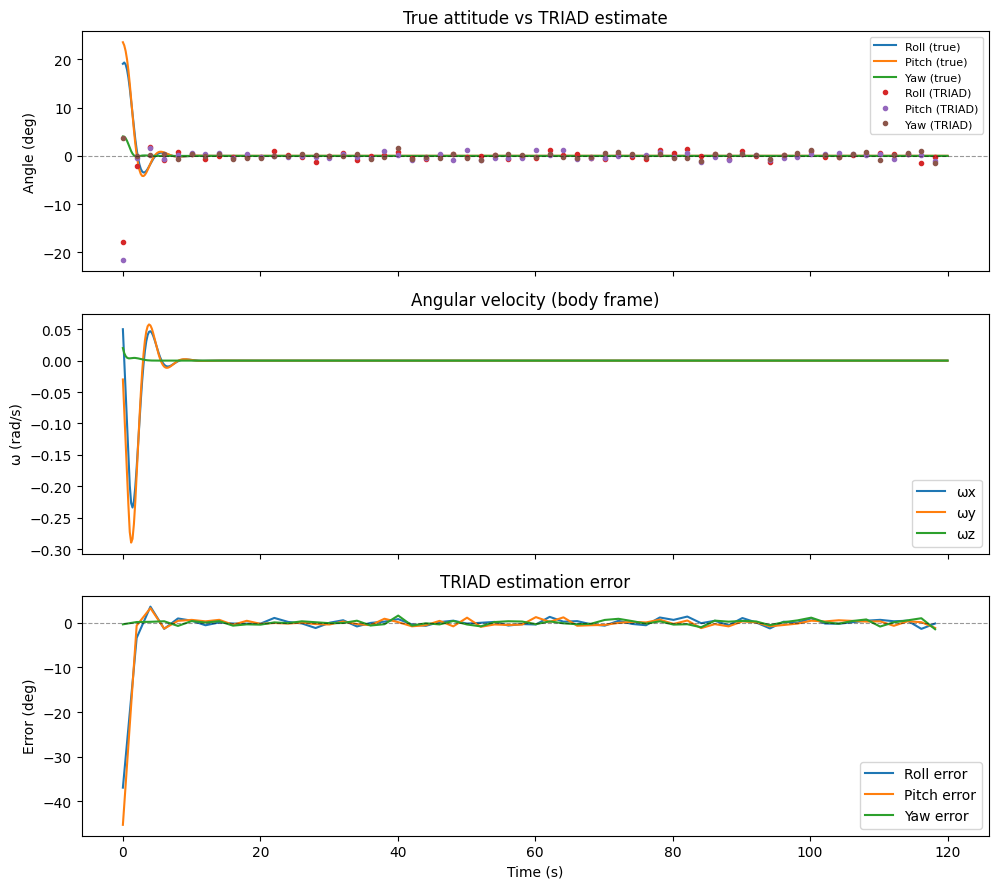

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# True euler angles
axes[0].plot(sol.t, eulers[:, 0], label='Roll (true)')
axes[0].plot(sol.t, eulers[:, 1], label='Pitch (true)')
axes[0].plot(sol.t, eulers[:, 2], label='Yaw (true)')
# TRIAD estimates (dots so you can see the difference)
axes[0].plot(triad_times, triad_eulers[:, 0], 'o', ms=3, label='Roll (TRIAD)')
axes[0].plot(triad_times, triad_eulers[:, 1], 'o', ms=3, label='Pitch (TRIAD)')
axes[0].plot(triad_times, triad_eulers[:, 2], 'o', ms=3, label='Yaw (TRIAD)')
axes[0].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[0].set_ylabel('Angle (deg)')
axes[0].set_title('True attitude vs TRIAD estimate')
axes[0].legend(fontsize=8)

# Angular velocity
axes[1].plot(sol.t, ws[:, 0], label='ωx')
axes[1].plot(sol.t, ws[:, 1], label='ωy')
axes[1].plot(sol.t, ws[:, 2], label='ωz')
axes[1].set_ylabel('ω (rad/s)')
axes[1].set_title('Angular velocity (body frame)')
axes[1].legend()

# TRIAD estimation error over time
estimation_error = triad_eulers - eulers[::10]
axes[2].plot(triad_times, estimation_error[:, 0], label='Roll error')
axes[2].plot(triad_times, estimation_error[:, 1], label='Pitch error')
axes[2].plot(triad_times, estimation_error[:, 2], label='Yaw error')
axes[2].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[2].set_ylabel('Error (deg)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('TRIAD estimation error')
axes[2].legend()

plt.tight_layout()
plt.show()

In [3]:
plt.savefig('cubesat_adcs.pdf')

<Figure size 640x480 with 0 Axes>

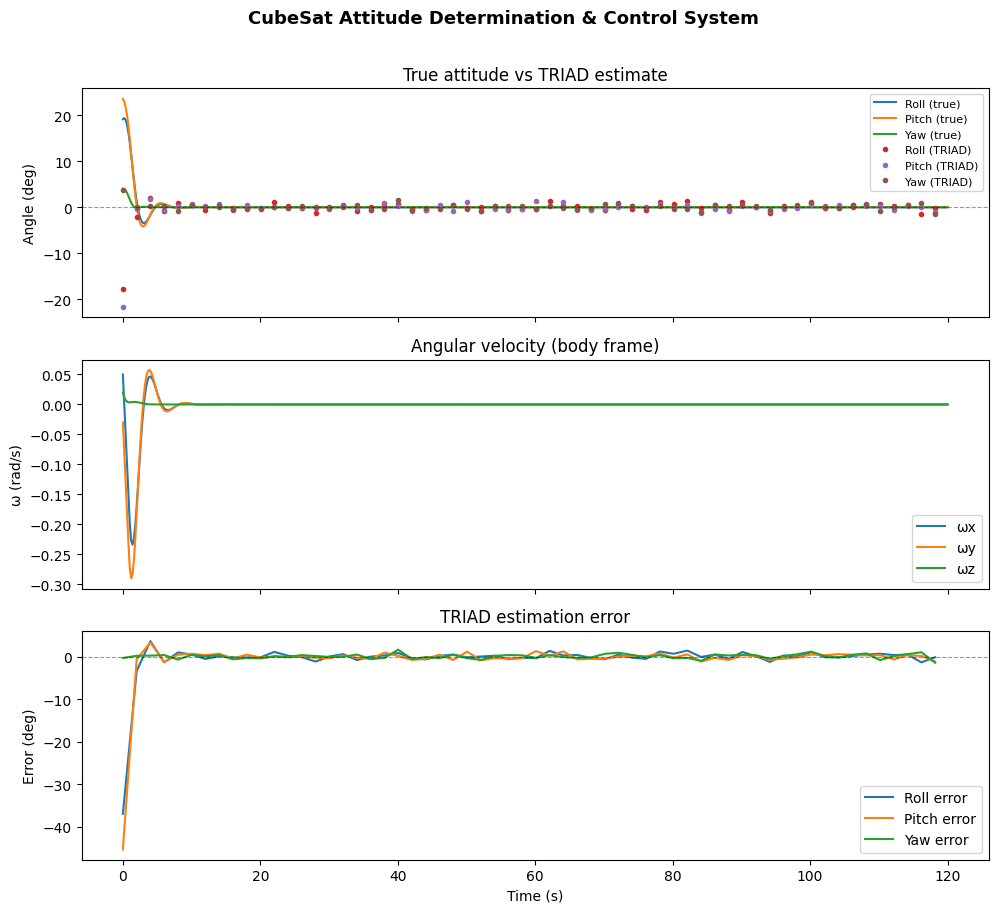

Saved as cubesat_adcs.pdf and cubesat_adcs.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(sol.t, eulers[:, 0], label='Roll (true)')
axes[0].plot(sol.t, eulers[:, 1], label='Pitch (true)')
axes[0].plot(sol.t, eulers[:, 2], label='Yaw (true)')
axes[0].plot(triad_times, triad_eulers[:, 0], 'o', ms=3, label='Roll (TRIAD)')
axes[0].plot(triad_times, triad_eulers[:, 1], 'o', ms=3, label='Pitch (TRIAD)')
axes[0].plot(triad_times, triad_eulers[:, 2], 'o', ms=3, label='Yaw (TRIAD)')
axes[0].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[0].set_ylabel('Angle (deg)')
axes[0].set_title('True attitude vs TRIAD estimate')
axes[0].legend(fontsize=8)

axes[1].plot(sol.t, ws[:, 0], label='ωx')
axes[1].plot(sol.t, ws[:, 1], label='ωy')
axes[1].plot(sol.t, ws[:, 2], label='ωz')
axes[1].set_ylabel('ω (rad/s)')
axes[1].set_title('Angular velocity (body frame)')
axes[1].legend()

estimation_error = triad_eulers - eulers[::10]
axes[2].plot(triad_times, estimation_error[:, 0], label='Roll error')
axes[2].plot(triad_times, estimation_error[:, 1], label='Pitch error')
axes[2].plot(triad_times, estimation_error[:, 2], label='Yaw error')
axes[2].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
axes[2].set_ylabel('Error (deg)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('TRIAD estimation error')
axes[2].legend()

plt.suptitle('CubeSat Attitude Determination & Control System', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

# Save BEFORE show
plt.savefig('cubesat_adcs.pdf', bbox_inches='tight')
plt.savefig('cubesat_adcs.png', dpi=150, bbox_inches='tight')

plt.show()
print("Saved as cubesat_adcs.pdf and cubesat_adcs.png")